In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

import re
import nltk
import pymorphy3


In [2]:
df2 = pd.read_csv('habr.csv')

In [3]:
df2.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub
0,0,Сэм Альтман критикует кибермодель Mythos от An...,BotHub,Bothub — экосистема AI инструментов,"381,71","Блог компании BotHub, Искусственный интеллект,...",2026-04-21,OpenAI и Anthropic продолжают обмениваться вза...
1,1,Opus 4.7 — худший релиз в истории Anthropic?,BotHub,Bothub — экосистема AI инструментов,"381,71","Блог компании BotHub, Искусственный интеллект,...",2026-04-21,"Сегодня Борис Черный выкатил тред о том, как в..."
2,2,Коучинговые инструменты: 4 техники для мотивац...,OTUS,"Развиваем технологии, обучая их создателей","699,13",Блог компании OTUS,2026-04-21,"Всем привет, меня зовут Сергей Прощаев. Я Tech..."
3,3,AGI уже стучится в дверь человечества. А мы вс...,Timeweb Cloud,То самое облако,"1 556,8","Блог компании Timeweb Cloud, Искусственный инт...",2026-04-21,Просто представьте на миг: вы — один из тех уч...
4,4,Топ 12 сервисов и нейросетей для генерации изо...,BotHub,Bothub — экосистема AI инструментов,"381,71","Блог компании BotHub, Искусственный интеллект,...",2026-04-21,Мир нейросетей не стоит на месте и движется вп...


In [4]:
df = pd.read_csv('All_pdf_stats.csv')

In [5]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub
0,0,AGI уже стучится в дверь человечества. А мы вс...,Timeweb Cloud,То самое облако,"1 560,8","Блог компании Timeweb Cloud, Искусственный ин...",2026-04-22,256K+\nОхват за 30 дней\nTimeweb Cloud\nТо сам...
1,1,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",MWS AI,Создаем решения будущего уже сегодня,"78,94","Блог компании MWS AI, Блог компании МТС, Маш...",2026-04-22,8K+\nОхват за 30 дней\nMWS AI\nСоздаем решения...
2,2,"Claude Code теперь требует паспорт, а Codex ум...",Haulmont,Корпоративные системы и инструменты разработчика,"201,84","Блог компании Haulmont, Программирование",2026-04-22,64K+\nОхват за 30 дней\nHaulmont\nКорпоративны...
3,3,"Microsoft заверила, что Windows 11 прекрасно о...",BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Операционные системы, ...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...
4,4,Opus 4.7 — худший релиз в истории Anthropic_,BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Искусственный интеллект...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...


In [6]:
df = pd.concat([df, df2], ignore_index=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   30 non-null     int64 
 1   title        30 non-null     object
 2   namecompany  30 non-null     object
 3   description  30 non-null     object
 4   rating       30 non-null     object
 5   field        30 non-null     object
 6   date         30 non-null     object
 7   textpub      30 non-null     object
dtypes: int64(1), object(7)
memory usage: 2.0+ KB


In [8]:
df['description'][0]

'То самое облако'

In [9]:
# формирование корпуса
df['corpus'] = (df['title'].fillna('') + ' ' + 
                df['description'].fillna(''))

### Предобработка текста

In [10]:
st = '\xa0—'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [11]:
df['prep_text']= [remove_othersymbol(text.lower()) for text in df['corpus']]

In [12]:
df['prep_text'][0]

'agi уже стучится в дверь человечества. а мы всё ещё думаем, что он станет нашим лучшим другом то самое облако'

In [13]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [14]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [15]:
df['prep_text']= [remove_punctuation(text) for text in df['prep_text']]

In [16]:
df['prep_text'][0]

'agi уже стучится в дверь человечества а мы всё ещё думаем что он станет нашим лучшим другом то самое облако'

In [17]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text
0,0,AGI уже стучится в дверь человечества. А мы вс...,Timeweb Cloud,То самое облако,"1 560,8","Блог компании Timeweb Cloud, Искусственный ин...",2026-04-22,256K+\nОхват за 30 дней\nTimeweb Cloud\nТо сам...,AGI уже стучится в дверь человечества. А мы вс...,agi уже стучится в дверь человечества а мы всё...
1,1,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",MWS AI,Создаем решения будущего уже сегодня,"78,94","Блог компании MWS AI, Блог компании МТС, Маш...",2026-04-22,8K+\nОхват за 30 дней\nMWS AI\nСоздаем решения...,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",asr на cpu как выбрать бэкенд настроить triton...
2,2,"Claude Code теперь требует паспорт, а Codex ум...",Haulmont,Корпоративные системы и инструменты разработчика,"201,84","Блог компании Haulmont, Программирование",2026-04-22,64K+\nОхват за 30 дней\nHaulmont\nКорпоративны...,"Claude Code теперь требует паспорт, а Codex ум...",claude code теперь требует паспорт а codex уме...
3,3,"Microsoft заверила, что Windows 11 прекрасно о...",BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Операционные системы, ...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,"Microsoft заверила, что Windows 11 прекрасно о...",microsoft заверила что windows 11 прекрасно об...
4,4,Opus 4.7 — худший релиз в истории Anthropic_,BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Искусственный интеллект...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,Opus 4.7 — худший релиз в истории Anthropic_ B...,opus 47 худший релиз в истории anthropic bot...


In [18]:
russian_stopwords = stopwords.words("russian") 

In [19]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный','фильм', 'кино', 'смотреть', 'год', 'снят', 'рассказывает', 'история', 
               'оказывается', 'вдруг', 'наконец', 'также', 'который', 'который', 'этот', 'эта', 'это', 'эти']) 

In [20]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rafael\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [22]:
%%time
lemm_texts_list = []
for text in (df['prep_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 78.1 ms
Wall time: 115 ms


In [23]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm
0,0,AGI уже стучится в дверь человечества. А мы вс...,Timeweb Cloud,То самое облако,"1 560,8","Блог компании Timeweb Cloud, Искусственный ин...",2026-04-22,256K+\nОхват за 30 дней\nTimeweb Cloud\nТо сам...,AGI уже стучится в дверь человечества. А мы вс...,agi уже стучится в дверь человечества а мы всё...,agi уже стучаться в дверь человечество а мы вс...
1,1,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",MWS AI,Создаем решения будущего уже сегодня,"78,94","Блог компании MWS AI, Блог компании МТС, Маш...",2026-04-22,8K+\nОхват за 30 дней\nMWS AI\nСоздаем решения...,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",asr на cpu как выбрать бэкенд настроить triton...,asr на cpu как выбрать бэкенд настроить triton...
2,2,"Claude Code теперь требует паспорт, а Codex ум...",Haulmont,Корпоративные системы и инструменты разработчика,"201,84","Блог компании Haulmont, Программирование",2026-04-22,64K+\nОхват за 30 дней\nHaulmont\nКорпоративны...,"Claude Code теперь требует паспорт, а Codex ум...",claude code теперь требует паспорт а codex уме...,claude code теперь требовать паспорт а codex у...
3,3,"Microsoft заверила, что Windows 11 прекрасно о...",BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Операционные системы, ...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,"Microsoft заверила, что Windows 11 прекрасно о...",microsoft заверила что windows 11 прекрасно об...,microsoft заверить что windows 11 прекрасно об...
4,4,Opus 4.7 — худший релиз в истории Anthropic_,BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Искусственный интеллект...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,Opus 4.7 — худший релиз в истории Anthropic_ B...,opus 47 худший релиз в истории anthropic bot...,opus 47 плохой релиз в история anthropic bothu...


In [24]:
df['text_lemm'][0]

'agi уже стучаться в дверь человечество а мы всё ещё думать что он стать наш хороший друг то самый облако'

In [25]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(t) > 2]
    text = " ".join(tokens)
    return text

In [26]:
df['tokenize_text'] = [tokenize(text) for text in df['text_lemm']]

In [27]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text
0,0,AGI уже стучится в дверь человечества. А мы вс...,Timeweb Cloud,То самое облако,"1 560,8","Блог компании Timeweb Cloud, Искусственный ин...",2026-04-22,256K+\nОхват за 30 дней\nTimeweb Cloud\nТо сам...,AGI уже стучится в дверь человечества. А мы вс...,agi уже стучится в дверь человечества а мы всё...,agi уже стучаться в дверь человечество а мы вс...,agi стучаться дверь человечество думать стать ...
1,1,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",MWS AI,Создаем решения будущего уже сегодня,"78,94","Блог компании MWS AI, Блог компании МТС, Маш...",2026-04-22,8K+\nОхват за 30 дней\nMWS AI\nСоздаем решения...,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",asr на cpu как выбрать бэкенд настроить triton...,asr на cpu как выбрать бэкенд настроить triton...,asr cpu выбрать бэкенд настроить triton потеря...
2,2,"Claude Code теперь требует паспорт, а Codex ум...",Haulmont,Корпоративные системы и инструменты разработчика,"201,84","Блог компании Haulmont, Программирование",2026-04-22,64K+\nОхват за 30 дней\nHaulmont\nКорпоративны...,"Claude Code теперь требует паспорт, а Codex ум...",claude code теперь требует паспорт а codex уме...,claude code теперь требовать паспорт а codex у...,claude code требовать паспорт codex уметь рабо...
3,3,"Microsoft заверила, что Windows 11 прекрасно о...",BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Операционные системы, ...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,"Microsoft заверила, что Windows 11 прекрасно о...",microsoft заверила что windows 11 прекрасно об...,microsoft заверить что windows 11 прекрасно об...,microsoft заверить windows 11 прекрасно обходи...
4,4,Opus 4.7 — худший релиз в истории Anthropic_,BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Искусственный интеллект...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,Opus 4.7 — худший релиз в истории Anthropic_ B...,opus 47 худший релиз в истории anthropic bot...,opus 47 плохой релиз в история anthropic bothu...,opus 47 плохой релиз anthropic bothub экосисте...


In [28]:
df['tokenize_text'][0]

'agi стучаться дверь человечество думать стать наш хороший друг самый облако'

In [29]:
pip install WordCloud

Note: you may need to restart the kernel to use updated packages.


In [30]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [31]:
# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

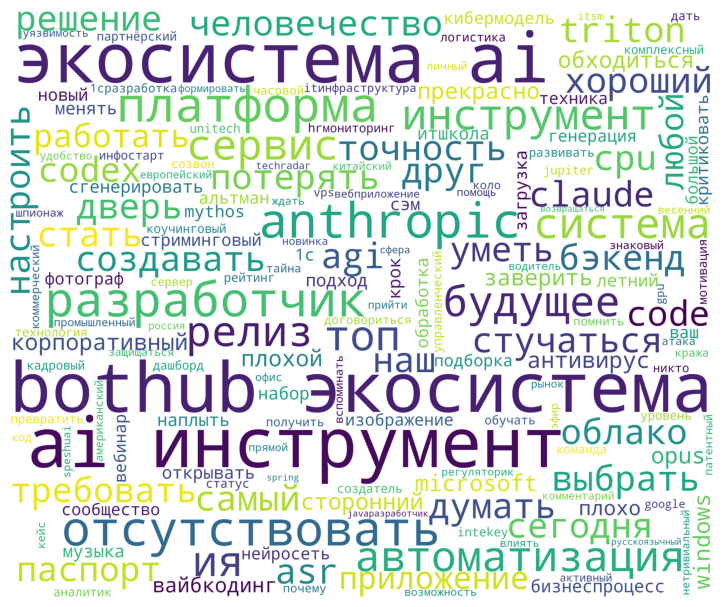

In [32]:
corpus = get_corpus(df['tokenize_text'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

In [33]:
# Получение облака слов
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

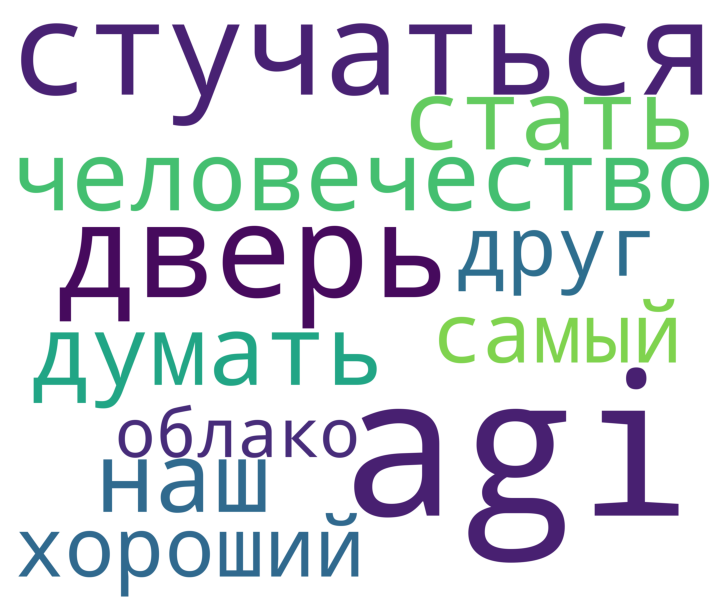

In [34]:
corpus = df['tokenize_text'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

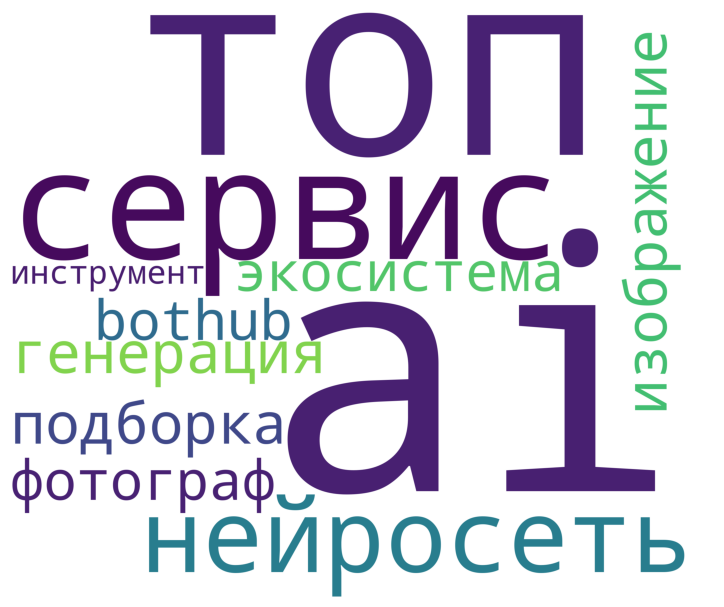

In [35]:
corpus = df['tokenize_text'][9]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

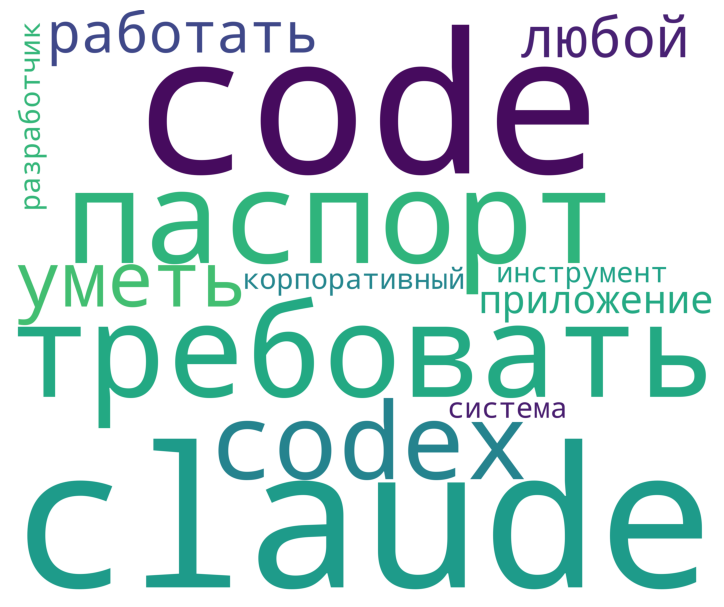

In [36]:
corpus = df['tokenize_text'][2]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

In [37]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text
0,0,AGI уже стучится в дверь человечества. А мы вс...,Timeweb Cloud,То самое облако,"1 560,8","Блог компании Timeweb Cloud, Искусственный ин...",2026-04-22,256K+\nОхват за 30 дней\nTimeweb Cloud\nТо сам...,AGI уже стучится в дверь человечества. А мы вс...,agi уже стучится в дверь человечества а мы всё...,agi уже стучаться в дверь человечество а мы вс...,agi стучаться дверь человечество думать стать ...
1,1,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",MWS AI,Создаем решения будущего уже сегодня,"78,94","Блог компании MWS AI, Блог компании МТС, Маш...",2026-04-22,8K+\nОхват за 30 дней\nMWS AI\nСоздаем решения...,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",asr на cpu как выбрать бэкенд настроить triton...,asr на cpu как выбрать бэкенд настроить triton...,asr cpu выбрать бэкенд настроить triton потеря...
2,2,"Claude Code теперь требует паспорт, а Codex ум...",Haulmont,Корпоративные системы и инструменты разработчика,"201,84","Блог компании Haulmont, Программирование",2026-04-22,64K+\nОхват за 30 дней\nHaulmont\nКорпоративны...,"Claude Code теперь требует паспорт, а Codex ум...",claude code теперь требует паспорт а codex уме...,claude code теперь требовать паспорт а codex у...,claude code требовать паспорт codex уметь рабо...
3,3,"Microsoft заверила, что Windows 11 прекрасно о...",BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Операционные системы, ...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,"Microsoft заверила, что Windows 11 прекрасно о...",microsoft заверила что windows 11 прекрасно об...,microsoft заверить что windows 11 прекрасно об...,microsoft заверить windows 11 прекрасно обходи...
4,4,Opus 4.7 — худший релиз в истории Anthropic_,BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Искусственный интеллект...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,Opus 4.7 — худший релиз в истории Anthropic_ B...,opus 47 худший релиз в истории anthropic bot...,opus 47 плохой релиз в история anthropic bothu...,opus 47 плохой релиз anthropic bothub экосисте...


# Векторизация текстовых данных

### Bag of words

In [38]:
# CountVectorizer для LDA (LDA лучше работает с частотами)
count_vec = CountVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3), analyzer='word')
count_matrix = count_vec.fit_transform(df['tokenize_text'])

feature_names = count_vec.get_feature_names_out()

In [39]:
len(count_vec.vocabulary_)

23

In [40]:
count_matrix.shape

(30, 23)

In [41]:
feature_names

array(['2026', 'ai', 'ai инструмент', 'anthropic', 'anthropic bothub',
       'anthropic bothub экосистема', 'bothub', 'bothub экосистема',
       'bothub экосистема ai', 'автоматизация', 'будущее', 'инструмент',
       'ия', 'отсутствовать', 'платформа', 'разработчик', 'релиз',
       'сервис', 'система', 'топ', 'экосистема', 'экосистема ai',
       'экосистема ai инструмент'], dtype=object)

### TF-IDF

TF (Term Frequency) — __Частота термина__
Показывает, как часто слово встречается в конкретном документе.

IDF (Inverse Document Frequency) — __Обратная частота документа__
Показывает, насколько слово редкое или уникальное во всем корпусе. Чем чаще слово встречается в разных документах, тем менее оно важно

Объединяет TF и IDF, чтобы оценить уникальную важность слова в документе на фоне всего корпуса.

In [42]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,          # игнорировать слова, встречающиеся в >70% документов
    min_df=3,            # игнорировать слова, встречающиеся менее чем в 3 документах
    max_features=5000,   # ограничить размер словаря
    ngram_range=(1, 3),  
    analyzer='word'
)

In [43]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenize_text'])

In [44]:
tfidf_matrix.shape

(30, 23)

In [45]:
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 142 stored elements and shape (30, 23)>
  Coords	Values
  (1, 10)	1.0
  (2, 18)	0.6733151809538209
  (2, 11)	0.3965470260982585
  (2, 15)	0.6240169254032701
  (3, 11)	0.2975593137923612
  (3, 6)	0.3375386005287801
  (3, 20)	0.3375386005287801
  (3, 1)	0.3375386005287801
  (3, 7)	0.3375386005287801
  (3, 21)	0.3375386005287801
  (3, 2)	0.3375386005287801
  (3, 8)	0.3375386005287801
  (3, 22)	0.3375386005287801
  (4, 11)	0.21513559945105445
  (4, 6)	0.2440406527261365
  (4, 20)	0.2440406527261365
  (4, 1)	0.2440406527261365
  (4, 7)	0.2440406527261365
  (4, 21)	0.2440406527261365
  (4, 2)	0.2440406527261365
  (4, 8)	0.2440406527261365
  (4, 22)	0.2440406527261365
  (4, 16)	0.3652884917565938
  (4, 3)	0.33854308941651656
  (4, 4)	0.33854308941651656
  :	:
  (19, 6)	0.277969893917461
  (19, 20)	0.277969893917461
  (19, 1)	0.277969893917461
  (19, 7)	0.277969893917461
  (19, 21)	0.277969893917461
  (19, 2)	0.277969893917461
  (19

In [46]:
tfidf_vectorizer.get_feature_names_out()[150:160]

array([], dtype=object)

# Тематическое моделирование

Тематическое моделирование позволяет выделять из текстов темы, связанные с определенными множествами слов, и затем смотреть, с какой вероятностью тексты соотносятся с этими темами. 

Библиотека **gensim**. Это популярная открытая библиотека для тематического моделирования, в которой есть нужная модель — LDA (Латентном размещении Дирихле (LDA)). Cледует создать словарь для тематического моделирования из лемматизированного текста. 

После создания словаря лучше всего отфильтровать те слова, которые встречаются в слишком большом количестве текстов, и те, которые встречаются слишком редко. Для этого есть метод filter_extremes, который принимает в себя аргументы no_above (только слова, которые встречаются не более чем в указанной доле текстов) и no_below (слова, которые встречаются не менее чем в указанном количестве текстов). 

После удаления лишних слов словарь лучше всего ужать в размерах, убрав пропуски.

In [47]:
import gensim

In [48]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    return tokens

In [49]:
df['tokenize_text3'] = [tokenize2(text) for text in df['tokenize_text']]

In [50]:
gensim_dictionary = gensim.corpora.Dictionary(df['tokenize_text3'])
gensim_dictionary.filter_extremes(no_above=0.5, no_below=2)
gensim_dictionary.compactify()

In [51]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df['tokenize_text3']]

In [52]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text,tokenize_text3
0,0,AGI уже стучится в дверь человечества. А мы вс...,Timeweb Cloud,То самое облако,"1 560,8","Блог компании Timeweb Cloud, Искусственный ин...",2026-04-22,256K+\nОхват за 30 дней\nTimeweb Cloud\nТо сам...,AGI уже стучится в дверь человечества. А мы вс...,agi уже стучится в дверь человечества а мы всё...,agi уже стучаться в дверь человечество а мы вс...,agi стучаться дверь человечество думать стать ...,"[agi, стучаться, дверь, человечество, думать, ..."
1,1,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",MWS AI,Создаем решения будущего уже сегодня,"78,94","Блог компании MWS AI, Блог компании МТС, Маш...",2026-04-22,8K+\nОхват за 30 дней\nMWS AI\nСоздаем решения...,"ASR на CPU. Как выбрать бэкенд, настроить Trit...",asr на cpu как выбрать бэкенд настроить triton...,asr на cpu как выбрать бэкенд настроить triton...,asr cpu выбрать бэкенд настроить triton потеря...,"[asr, cpu, выбрать, бэкенд, настроить, triton,..."
2,2,"Claude Code теперь требует паспорт, а Codex ум...",Haulmont,Корпоративные системы и инструменты разработчика,"201,84","Блог компании Haulmont, Программирование",2026-04-22,64K+\nОхват за 30 дней\nHaulmont\nКорпоративны...,"Claude Code теперь требует паспорт, а Codex ум...",claude code теперь требует паспорт а codex уме...,claude code теперь требовать паспорт а codex у...,claude code требовать паспорт codex уметь рабо...,"[claude, code, требовать, паспорт, codex, умет..."
3,3,"Microsoft заверила, что Windows 11 прекрасно о...",BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Операционные системы, ...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,"Microsoft заверила, что Windows 11 прекрасно о...",microsoft заверила что windows 11 прекрасно об...,microsoft заверить что windows 11 прекрасно об...,microsoft заверить windows 11 прекрасно обходи...,"[microsoft, заверить, windows, 11, прекрасно, ..."
4,4,Opus 4.7 — худший релиз в истории Anthropic_,BotHub,Bothub — экосистема AI инструментов,"383,71","Блог компании BotHub, Искусственный интеллект...",2026-04-22,512K+\nОхват за 30 дней\nBotHub\nBothub — экос...,Opus 4.7 — худший релиз в истории Anthropic_ B...,opus 47 худший релиз в истории anthropic bot...,opus 47 плохой релиз в история anthropic bothu...,opus 47 плохой релиз anthropic bothub экосисте...,"[opus, 47, плохой, релиз, anthropic, bothub, э..."


In [53]:
data_for_ml = df[['tokenize_text']]
data_for_ml.to_csv('stats_for_ml.csv',index=False,encoding='utf-8-sig')

In [54]:
corpus

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1)],
 [(11, 1),
  (12, 1),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1)],
 [(23, 1),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1)],
 [(26, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 1)],
 [(26, 1),
  (37, 1),
  (38, 1),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1)],
 [(52, 1), (53, 1), (54, 1), (55, 1), (56, 1)],
 [(57, 1), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1)],
 [(26, 1),
  (37, 1),
  (38, 1),
  (46, 1),
  (55, 1),
  (63, 1),
  (64, 1),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 1),
  (71, 1),
  (72, 1)],
 [(26, 1),
  (37, 1),
  (38, 1),
  (46, 1),
  (48, 1),
  (73, 1),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 1

In [55]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=7, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [56]:
lda_20.print_topics()

[(0,
  '0.043*"2026" + 0.043*"летний" + 0.043*"крок" + 0.043*"набор" + 0.043*"итшкола" + 0.043*"открывать" + 0.043*"самый" + 0.043*"стать" + 0.043*"хороший" + 0.043*"облако"'),
 (1,
  '0.081*"bothub" + 0.081*"инструмент" + 0.081*"экосистема" + 0.081*"ai" + 0.081*"anthropic" + 0.042*"релиз" + 0.042*"плохой" + 0.042*"opus" + 0.042*"47" + 0.042*"альтман"'),
 (2,
  '0.130*"автоматизация" + 0.089*"платформа" + 0.089*"плохо" + 0.089*"вайбкодинг" + 0.089*"бизнеспроцесс" + 0.006*"экосистема" + 0.006*"mythos" + 0.006*"сэм" + 0.006*"ai" + 0.006*"инструмент"'),
 (3,
  '0.067*"вебинар" + 0.067*"отсутствовать" + 0.067*"ваш" + 0.067*"релиз" + 0.009*"автоматизация" + 0.008*"техника" + 0.008*"разработчик" + 0.008*"инструмент" + 0.008*"сообщество" + 0.008*"ai"'),
 (4,
  '0.058*"инструмент" + 0.058*"экосистема" + 0.058*"заверить" + 0.058*"windows" + 0.058*"bothub" + 0.058*"обходиться" + 0.058*"антивирус" + 0.058*"11" + 0.058*"сторонний" + 0.058*"microsoft"'),
 (5,
  '0.046*"разработчик" + 0.046*"система

In [57]:
from sklearn.decomposition import LatentDirichletAllocation

In [58]:
n_topics = 7
n_top_words = 10

print("\n" + "="*60)
print("LDA (Латентное размещение Дирихле)")
print("="*60)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(count_matrix)

def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print()

print_topics(lda, feature_names, n_top_words)


LDA (Латентное размещение Дирихле)
Тема 1:
2026 инструмент релиз ия топ платформа будущее разработчик сервис отсутствовать

Тема 2:
ai инструмент экосистема ai инструмент экосистема ai экосистема bothub экосистема ai bothub экосистема bothub ai инструмент 2026

Тема 3:
сервис 2026 инструмент релиз ия топ платформа будущее разработчик отсутствовать

Тема 4:
2026 инструмент релиз ия топ платформа будущее разработчик сервис отсутствовать

Тема 5:
инструмент экосистема ai экосистема ai инструмент bothub экосистема bothub bothub экосистема ai экосистема ai инструмент anthropic bothub экосистема anthropic

Тема 6:
автоматизация будущее платформа ия 2026 инструмент релиз топ разработчик сервис

Тема 7:
отсутствовать разработчик система инструмент 2026 топ релиз ия платформа будущее



In [59]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [60]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [61]:
pyLDAvis.enable_notebook()

In [62]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6      0.145436 -0.019317       1        1  26.925531
5     -0.145081  0.197340       2        1  23.002517
1      0.164921  0.005404       3        1  16.033261
0     -0.167800 -0.177358       4        1  15.348772
4      0.104907  0.002535       5        1  10.851770
2     -0.057516 -0.010726       6        1   5.207408
3     -0.044867  0.002123       7        1   2.630742, topic_info=             Term      Freq     Total Category  logprob  loglift
52  автоматизация  2.000000  2.000000  Default  30.0000  30.0000
55      платформа  3.000000  3.000000  Default  29.0000  29.0000
37             ai  9.000000  9.000000  Default  28.0000  28.0000
87  отсутствовать  3.000000  3.000000  Default  27.0000  27.0000
51          релиз  2.000000  2.000000  Default  26.0000  26.0000
..            ...       ...       ...      ...      ...      ...
83         сервис  0.052124  3.073299   Topic7  -4.7801  -0.4390
57           2026  0.052124  3.718165   Topic7  -4.7801  -0.6295
48      anthropic  0.052124  3.630228   Topic7  -4.7801  -0.6055
75    кибермодель  0.052124  2.145621   Topic7  -4.7801  -0.0797
73         mythos  0.052124  2.145557   Topic7  -4.7801  -0.0796

[311 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
36        5  0.488511            11
78        1  0.881362            12
57        1  0.537900          2026
57        4  0.537900          2026
47        3  0.932111            47
...     ...       ...           ...
9         4  0.947865       хороший
10        4  0.947865  человечество
46        1  0.364412    экосистема
46        3  0.364412    экосистема
46        5  0.121471    экосистема

[108 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 6, 2, 1, 5, 3, 4])

LDA - это метод машинного обучения, который используется для анализа тематической структуры в больших наборах документов. Который использует модель вероятности, чтобы определить, какие темы присутствуют в каждом документе, и какие слова связаны с каждой темой. LDA может быть полезен в случаях, когда нужно опредлить тематическую структуру в большом наборе документов, таких как статьи и т.д.

In [63]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(model=lda_20,
                                 texts=df['tokenize_text3'],
                                 dictionary=gensim_dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

Когерентность модели: 0.3704867227746752


CoherenceModel — это класс из библиотеки Gensim, который используется для оценки качества тематической модели (например, LDA) с помощью метрики когерентности (coherence). Когерентность измеряет, насколько хорошо темы, выявленные моделью, соответствуют человеческому восприятию. Чем выше когерентность, тем более интерпретируемыми и осмысленными являются темы.

In [64]:
from sklearn.decomposition import LatentDirichletAllocation

In [65]:
# создание модели LDA
lda_model = LatentDirichletAllocation(n_components=7, random_state=0)
lda_model.fit(count_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([count_vec.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: ai, экосистема, экосистема ai, ai инструмент, bothub экосистема, bothub экосистема ai, bothub, экосистема ai инструмент, инструмент, anthropic bothub экосистема
Topic 1: 2026, сервис, платформа, инструмент, ия, релиз, топ, разработчик, отсутствовать, система
Topic 2: инструмент, разработчик, система, 2026, сервис, платформа, ия, релиз, топ, отсутствовать
Topic 3: будущее, ия, 2026, сервис, платформа, инструмент, релиз, топ, разработчик, отсутствовать
Topic 4: отсутствовать, топ, разработчик, система, 2026, сервис, платформа, инструмент, ия, релиз
Topic 5: автоматизация, платформа, 2026, отсутствовать, сервис, инструмент, ия, топ, релиз, разработчик
Topic 6: релиз, сервис, отсутствовать, 2026, платформа, инструмент, ия, топ, разработчик, система


In [66]:
lda_model = LatentDirichletAllocation(learning_method='online', random_state=5, n_jobs=-1, n_components=11)
lda_model.fit(tfidf_matrix)

LatentDirichletAllocation(learning_method='online', n_components=11, n_jobs=-1,
                          random_state=5)

In [67]:
#датафрейм для ключевых слов каждой темы
topic_keywords = pd.DataFrame()
for i,topic in enumerate(lda_model.components_):
    topic_keywords[f'Topic {i + 1}'] = [count_vec.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
topic_keywords

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11
0,bothub экосистема,anthropic,ai,система,bothub,bothub,релиз,anthropic bothub экосистема,anthropic bothub,автоматизация,bothub экосистема ai
1,экосистема ai,отсутствовать,разработчик,экосистема ai инструмент,ия,экосистема ai инструмент,инструмент,bothub экосистема ai,автоматизация,топ,экосистема
2,экосистема,экосистема ai,ai инструмент,будущее,anthropic bothub,экосистема ai,bothub экосистема ai,отсутствовать,anthropic bothub экосистема,система,экосистема ai инструмент
3,экосистема ai инструмент,разработчик,anthropic,платформа,anthropic,bothub экосистема,экосистема ai,bothub экосистема,система,bothub,ai
4,ai инструмент,anthropic bothub,автоматизация,bothub экосистема,топ,экосистема,bothub экосистема,разработчик,разработчик,отсутствовать,ai инструмент
5,платформа,2026,ия,ия,сервис,bothub экосистема ai,anthropic,anthropic,отсутствовать,инструмент,экосистема ai
6,ия,система,bothub,bothub экосистема ai,система,топ,anthropic bothub,2026,инструмент,ai,bothub
7,разработчик,топ,отсутствовать,инструмент,экосистема ai инструмент,отсутствовать,anthropic bothub экосистема,ия,bothub,anthropic bothub,anthropic bothub экосистема
8,инструмент,ия,сервис,топ,bothub экосистема ai,ai,отсутствовать,платформа,anthropic,bothub экосистема,anthropic
9,система,будущее,2026,автоматизация,разработчик,инструмент,система,автоматизация,экосистема ai,разработчик,anthropic bothub


NMF - это метод машинного обучения, который используется для разложения матрицы на две с неотрицательными элементами. Он может быть полезен в случаях, когда нужно найти скрытые признаки в данных, таких как тексты и т.д. NMF может использоваться в различных областях, таких как обработка изображений, текстовый анализ и т.д

NMF (Non-negative Matrix Factorization) — метод разложения матрицы на две неотрицательные матрицы:

__Исходная матрица (документы × слова) ≈ Матрица тем (документы × темы) × Матрица слов (темы × слова)__

Матрица слов содержит "слова-темы" и показывает, какие слова характеризуют каждую тему.

Матрица тем содержит "темы-документы" и показывает, насколько каждая тема присутствует в каждом документе.

In [68]:
from sklearn.decomposition import NMF

In [69]:
# создание модели NMF
nmf_model = NMF(n_components=10, random_state=0)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: ai, экосистема ai, экосистема ai инструмент, ai инструмент, bothub экосистема, bothub экосистема ai, экосистема, bothub, инструмент, ия
Topic 1: система, отсутствовать, разработчик, экосистема, топ, экосистема ai, экосистема ai инструмент, релиз, сервис, платформа
Topic 2: автоматизация, платформа, ия, топ, экосистема ai инструмент, экосистема ai, экосистема, релиз, сервис, система
Topic 3: будущее, ия, платформа, топ, экосистема ai инструмент, экосистема ai, экосистема, релиз, сервис, система
Topic 4: 2026, отсутствовать, ai, топ, инструмент, экосистема ai, экосистема ai инструмент, релиз, сервис, система
Topic 5: отсутствовать, релиз, топ, экосистема, экосистема ai, система, экосистема ai инструмент, сервис, разработчик, платформа
Topic 6: разработчик, топ, система, экосистема, экосистема ai, сервис, экосистема ai инструмент, релиз, платформа, отсутствовать
Topic 7: anthropic bothub, anthropic, anthropic bothub экосистема, bothub экосистема ai, экосистема ai инструмент, экос

In [70]:
# создание модели NMF
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: ai, экосистема ai, экосистема ai инструмент, ai инструмент, bothub экосистема, bothub экосистема ai, экосистема, bothub, инструмент, anthropic bothub экосистема
Topic 1: разработчик, система, инструмент, топ, отсутствовать, экосистема, экосистема ai инструмент, релиз, сервис, экосистема ai
Topic 2: автоматизация, платформа, ия, bothub экосистема ai, экосистема ai инструмент, экосистема ai, экосистема, bothub, ai инструмент, bothub экосистема
Topic 3: будущее, ия, платформа, система, отсутствовать, экосистема ai, экосистема ai инструмент, релиз, сервис, топ
Topic 4: 2026, отсутствовать, ai, топ, экосистема, экосистема ai, экосистема ai инструмент, bothub, bothub экосистема, ai инструмент
Topic 5: отсутствовать, релиз, система, топ, anthropic bothub, anthropic, anthropic bothub экосистема, сервис, экосистема ai инструмент, экосистема ai
Topic 6: сервис, топ, ai, разработчик, экосистема ai, экосистема, экосистема ai инструмент, bothub, ai инструмент, bothub экосистема


In [71]:
nmf_transformed = nmf_model.transform(tfidf_matrix)

print("\nТОП-3 Статьи для каждой темы:\n")
for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    top_docs_idx = np.argsort(topic_scores)[-5:][::-1]
    
    print(f" Topic {topic_idx}")
    for rank, doc_idx in enumerate(top_docs_idx[:3], 1):
        title = df.iloc[doc_idx]['title']
        rating = df.iloc[doc_idx]['rating']
        score = topic_scores[doc_idx]
        print(f"   {rank}. {title} (рейтинг: {rating}) — уверенность: {score:.3f}")
    print()


ТОП-3 Статьи для каждой темы:

 Topic 0
   1. Microsoft заверила, что Windows 11 прекрасно обходится без стороннего антивируса (рейтинг: 383,71) — уверенность: 0.461
   2. Microsoft заверила, что Windows 11 прекрасно обходится без стороннего антивируса (рейтинг: 381,71) — уверенность: 0.461
   3. Сэм Альтман критикует кибермодель Mythos от Anthropic (рейтинг: 381,71) — уверенность: 0.448

 Topic 1
   1. Claude Code теперь требует паспорт, а Codex умеет работать с (почти) любыми приложениями (рейтинг: 200,18) — уверенность: 0.533
   2. Claude Code теперь требует паспорт, а Codex умеет работать с (почти) любыми приложениями (рейтинг: 201,84) — уверенность: 0.533
   3. TechRadar для Java-разработчиков возвращается (рейтинг: 67,61) — уверенность: 0.422

 Topic 2
   1. Вайбкодинг — это плохо? (рейтинг: 324,65) — уверенность: 0.629
   2. Вайбкодинг — это плохо_ (рейтинг: 319,2) — уверенность: 0.629
   3. INTEKEY получила партнерский статус Unitech уровня Jupiter (рейтинг: 18,02) — увереннос

LSA - это метод машинного обучения, который используется для анализа структуры в больших наборах текстовых данных. Он использует матричные вычисления для определения близости между словами и документами. LSA может быть полезен в случаях, когда вы хотите определить структуру в большом наборе текстовых данных, таких как статьи, отчеты и т.д.

In [72]:
from sklearn.decomposition import TruncatedSVD

In [73]:
# создание модели LSA
lsa_model = TruncatedSVD(n_components=7, random_state=0)
lsa_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: ai, инструмент, экосистема ai инструмент, bothub экосистема ai, bothub экосистема, экосистема ai, экосистема, bothub, ai инструмент, anthropic bothub экосистема
Topic 1: разработчик, система, отсутствовать, инструмент, топ, 2026, релиз, сервис, будущее, ия
Topic 2: автоматизация, платформа, будущее, ия, разработчик, система, инструмент, отсутствовать, топ, bothub экосистема
Topic 3: будущее, ия, разработчик, система, инструмент, отсутствовать, топ, bothub, bothub экосистема, bothub экосистема ai
Topic 4: 2026, отсутствовать, сервис, топ, релиз, ai, автоматизация, будущее, платформа, ai инструмент
Topic 5: сервис, 2026, разработчик, топ, инструмент, ai, ия, платформа, bothub экосистема, ai инструмент
Topic 6: сервис, разработчик, топ, релиз, ai, автоматизация, anthropic, anthropic bothub экосистема, anthropic bothub, отсутствовать


Topic 0: Платформы-агрегаторы нейросетей

    О чем: Использование экосистемы BotHub для доступа к различным моделям (включая Anthropic/Claude). Обсуждение того, как удобнее использовать ИИ через единый интерфейс.

    Вердикт: Идеальное совпадение. Ключевые слова "bothub", "экосистема" и "ai инструмент" четко указывают на статьи-обзоры сервисов, которые объединяют разные нейросети в одном месте. Модель выделила бренд как центральный узел темы.

Topic 1: Прогнозы и релизы 2026 года

    О чем: Технологический ландшафт 2026 года, ожидаемые обновления софта и системные изменения в ИТ-индустрии.

    Вердикт: Полное совпадение. Ключи "2026", "релиз" и "будущее" подтверждают, что в этот топик попали статьи-прогнозы и анонсы инструментов, которые станут стандартом в ближайшее время.

Topic 2: Интеллектуальная автоматизация процессов

    О чем: Внедрение ИИ в рабочие процессы разработчиков, создание платформ, которые автоматизируют рутину.

    Вердикт: Совпало. Темы "автоматизация" и "платформа" здесь стоят рядом с "ия". Это указывает на технические статьи о том, как ИИ-инструменты интегрируются в реальные производственные системы.

Topic 3: Тренды и стратегия развития ИИ

    О чем: Глобальное влияние ИИ на работу разработчиков и стратегические изменения в разработке ПО.

    Вердикт: Совпало. Топик получился концептуальным. Ключи "будущее", "ия" и "система" объединяют статьи о том, куда движется индустрия в целом под давлением нейросетей.

Topic 4: Сервисы и системные обновления

    О чем: Обзоры новых ИТ-сервисов, вышедших в 2026 году, и решение проблемы "отсутствия" доступа к зарубежным инструментам.

    Вердикт: Полное совпадение. Слова "сервис" и "отсутствовать" явно указывают на статьи об импортозамещении или поиске альтернатив ушедшим с рынка инструментам.

Topic 5: Образование и инструментарий разработчика

    О чем: Обучение новым ИИ-инструментам, развитие навыков программистов в условиях 2026 года.

    Вердикт: Совпало. Связка "разработчик", "платформа" и "ai инструмент" говорит о статьях, обучающих работе с новыми стеками технологий.

Topic 6: Технический стек Anthropic и Claude

    О чем: Глубокая интеграция с моделями Anthropic, настройка доступа и использование их в разработке.

    Вердикт: Идеальное совпадение. Наличие специфического слова "anthropic" рядом с "сервис" и "релиз" выделяет эту компанию в отдельную важную ветку обсуждений на Хабре.

Итоговое заключение по проекту

    Анализ семантической плотности: Модель NMF продемонстрировала высокую разделительную способность на малом объеме данных (30 статей). Несмотря на общую направленность текстов на тематику ИИ, алгоритм четко разграничил брендовые запросы (Anthropic, BotHub), временные маркеры (прогнозы 2026) и функциональные задачи (автоматизация, сервисы).

    Практические инсайты: Исследование выявило, что ключевым трендом на Хабре в 2026 году является не разработка нейросетей «с нуля», а их интеграция в экосистемы. Темы 0 и 6 показывают, что профессиональное сообщество больше всего интересуется вопросами доступа к мировым моделям и созданием надстроек над ними для решения бизнес-задач.